# 03a — SARIMA Baseline (monthly, 1-month-ahead walk-forward)

Two SARIMA models for pan-Arctic ice extent, evaluated at **monthly** scale on the
**2020–2023** test set (matching the daily baselines' test *period*, at a coarser resolution):

1. **SARIMA_raw** — SARIMA(1,0,1)(0,1,1,12) on raw monthly extent
2. **SARIMA_anomaly** — SARIMA(2,0,2)(1,0,1,12) on monthly anomalies (extent − month-of-year mean)

**Evaluation protocol.** All monthly models produce **1-month-ahead** forecasts via
walk-forward: at each test month the model forecasts one step, then the *true* observation is
appended before forecasting the next month. This makes SARIMA directly comparable to the
1-month-ahead persistence baseline and parallels the daily +1-day setup in `03b`.

> **Scale caveat.** These monthly results are logged with `scale="monthly"` and are **not**
> directly comparable to the daily baselines in `03b` (`scale="daily"`): a 1-month-ahead forecast
> is a different, harder task than a 1-day-ahead forecast. Compare *within* a scale, using
> `create_comparison_table(filter_scale=...)`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import sqlalchemy
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

from src.data_utils import DATABASE_URL
from src.evaluation_utils import (
    compute_all_metrics,
    compute_seasonal_metrics,
    log_model_results,
    load_results,
    create_comparison_table,
)

## Load & aggregate to monthly

Load daily pan-Arctic extent directly from PostgreSQL (no ERA5 dependency) and aggregate to
monthly means. History starts 1989 to match the established SARIMA/LSTM training window.

In [3]:
engine = sqlalchemy.create_engine(DATABASE_URL)
daily = pd.read_sql(
    "SELECT date, extent_mkm2 FROM ice_extent_pan_arctic_daily "
    "WHERE date >= '1989-01-01' ORDER BY date",
    engine,
    parse_dates=["date"],
)

monthly = (
    daily.groupby(daily["date"].dt.to_period("M"))["extent_mkm2"].mean().to_frame()
)
monthly["month"] = monthly.index.month
monthly["ts"] = monthly.index.to_timestamp()
print(f"{len(monthly)} monthly obs: {monthly.index.min()} -> {monthly.index.max()}")
monthly.head()

450 monthly obs: 1989-01 -> 2026-06


,extent_mkm2,month,ts
date,,,
1989-01,14.954806,1,1989-01-01
1989-02,15.495536,2,1989-02-01
1989-03,15.423290,3,1989-03-01
1989-04,14.328400,4,1989-04-01
1989-05,13.044129,5,1989-05-01


## Train / test split & monthly climatology

Train = 1989-01 … 2019-12, test = 2020-01 … 2023-12 (48 months). The month-of-year climatology
(used both for the anomaly model and the climatology baseline) is computed on **train only**.

In [4]:
TEST_START = pd.Period("2020-01", freq="M")
TEST_END = pd.Period("2023-12", freq="M")

train = monthly[monthly.index < TEST_START].copy()
test = monthly[(monthly.index >= TEST_START) & (monthly.index <= TEST_END)].copy()

# Month-of-year climatology from training years only
month_clim = train.groupby("month")["extent_mkm2"].mean()

train["anomaly"] = train["extent_mkm2"] - train["month"].map(month_clim)
test["anomaly"] = test["extent_mkm2"] - test["month"].map(month_clim)

print(f"Train: {len(train)} months ({train.index.min()} -> {train.index.max()})")
print(f"Test:  {len(test)} months ({test.index.min()} -> {test.index.max()})")

y_true = test["extent_mkm2"].values
test_dates = pd.Series(test["ts"].values)

Train: 372 months (1989-01 -> 2019-12)
Test:  48 months (2020-01 -> 2023-12)


## Walk-forward helper

`SARIMAX.append(refit=False)` extends the fitted model with each new true observation without
re-estimating parameters — the standard, fast way to produce recursive 1-step-ahead forecasts.

In [5]:
def walk_forward(train_endog, test_endog, order, seasonal_order, **kw):
    # Recursive 1-step-ahead forecasts over the test set (params fixed from the train fit).
    res = SARIMAX(np.asarray(train_endog), order=order,
                  seasonal_order=seasonal_order, **kw).fit(disp=False)
    preds = []
    for actual in np.asarray(test_endog):
        preds.append(float(np.asarray(res.forecast(steps=1))[0]))
        res = res.append([actual], refit=False)
    return np.array(preds)

## Model 1 — SARIMA on raw extent

In [6]:
forecast_raw = walk_forward(
    train["extent_mkm2"], test["extent_mkm2"],
    order=(1, 0, 1), seasonal_order=(0, 1, 1, 12),
)
print("SARIMA_raw sample:", np.round(forecast_raw[:4], 3))

SARIMA_raw sample: [13.463 14.456 14.789 13.882]


## Model 2 — SARIMA on anomalies (converted back to raw extent)

In [7]:
forecast_anom = walk_forward(
    train["anomaly"], test["anomaly"],
    order=(2, 0, 2), seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False, enforce_invertibility=False,
)
# back to raw extent: anomaly forecast + month-of-year climatology
forecast_anom_raw = forecast_anom + test["month"].map(month_clim).values
print("SARIMA_anomaly sample:", np.round(forecast_anom_raw[:4], 3))

/home/catra/projects/arctic-ice-extent/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA_anomaly sample: [13.431 14.438 14.731 13.877]


## Monthly baselines (same 1-month-ahead framing)

- **Persistence** — next month equals this month: `ŷ[m] = y[m−1]` (first test month uses Dec 2019).
- **Climatology** — month-of-year mean from the training years.

In [8]:
persistence_pred = np.concatenate([[train["extent_mkm2"].values[-1]], y_true[:-1]])
climatology_pred = test["month"].map(month_clim).values

assert not np.isnan(persistence_pred).any()
assert not np.isnan(climatology_pred).any()

## Metrics & skill scores

In [9]:
models = {
    "SARIMA_raw": forecast_raw,
    "SARIMA_anomaly": forecast_anom_raw,
    "persistence": persistence_pred,
    "climatology": climatology_pred,
}

metrics = {}
for name, pred in models.items():
    m = compute_all_metrics(
        y_true=y_true, y_pred=pred,
        y_baseline_persistence=persistence_pred,
        y_baseline_climatology=climatology_pred,
        climatology=climatology_pred,
    )
    metrics[name] = m
    print(f"\n{name}  (monthly, 1-month-ahead)")
    for k, v in m.items():
        print(f"  {k:26s} {v:8.4f}")


SARIMA_raw  (monthly, 1-month-ahead)
  rmse                         0.2267
  mae                          0.1822
  mape                         2.3196
  skill_score_persistence      0.8812
  skill_score_climatology      0.7248
  anomaly_correlation          0.8554

SARIMA_anomaly  (monthly, 1-month-ahead)
  rmse                         0.2343
  mae                          0.1785
  mape                         2.2782
  skill_score_persistence      0.8773
  skill_score_climatology      0.7156
  anomaly_correlation          0.8435

persistence  (monthly, 1-month-ahead)
  rmse                         1.9088
  mae                          1.6766
  mape                        19.5612
  skill_score_persistence      0.0000
  skill_score_climatology     -1.3175
  anomaly_correlation          0.1018

climatology  (monthly, 1-month-ahead)
  rmse                         0.8237
  mae                          0.7013
  mape                         9.3315
  skill_score_persistence      0.5685
  skil

/home/catra/projects/arctic-ice-extent/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/catra/projects/arctic-ice-extent/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Seasonal breakdown (SARIMA models)

In [10]:
for name in ["SARIMA_raw", "SARIMA_anomaly"]:
    seasonal = compute_seasonal_metrics(
        y_true=y_true, y_pred=models[name], dates=test_dates,
        y_baseline_persistence=persistence_pred,
        y_baseline_climatology=climatology_pred,
    )
    print(f"\n{name} — seasonal (Mkm²)")
    for season in ["winter", "summer"]:
        s = seasonal[season]
        if s:
            print(f"  {season:6s} rmse={s['rmse']:.3f}  mae={s['mae']:.3f}  "
                  f"SS_pers={s.get('skill_score_persistence', float('nan')):.3f}")


SARIMA_raw — seasonal (Mkm²)
  winter rmse=0.127  mae=0.110  SS_pers=0.936
  summer rmse=0.267  mae=0.220  SS_pers=0.866

SARIMA_anomaly — seasonal (Mkm²)
  winter rmse=0.146  mae=0.122  SS_pers=0.927
  summer rmse=0.284  mae=0.229  SS_pers=0.858


## Logging

Written to `results/model_comparison.csv` with `scale="monthly"`. Idempotent: all prior monthly
rows are dropped before re-logging so re-runs don't duplicate.

In [11]:
results_file = PROJECT_ROOT / "results" / "model_comparison.csv"

if results_file.exists():
    prev = pd.read_csv(results_file)
    prev = prev[prev["scale"] != "monthly"]  # this notebook owns the monthly rows
    results_file.parent.mkdir(parents=True, exist_ok=True)
    prev.to_csv(results_file, index=False)

meta_common = {"aggregation": "monthly", "horizon": "1_month_ahead_walkforward",
               "train_period": "1989-2019", "test_period": "2020-2023"}
log_meta = {
    "SARIMA_raw": {**meta_common, "order": "(1,0,1)", "seasonal_order": "(0,1,1,12)", "data": "raw"},
    "SARIMA_anomaly": {**meta_common, "order": "(2,0,2)", "seasonal_order": "(1,0,1,12)", "data": "anomaly"},
    "persistence": {**meta_common, "type": "baseline", "method": "y[m]=y[m-1]"},
    "climatology": {**meta_common, "type": "baseline", "method": "month_of_year_mean"},
}
for name in models:
    log_model_results(name, metrics[name], scale="monthly",
                      metadata=log_meta[name], output_file=results_file)

✓ Logged results for SARIMA_raw to /home/catra/projects/arctic-ice-extent/results/model_comparison.csv
✓ Logged results for SARIMA_anomaly to /home/catra/projects/arctic-ice-extent/results/model_comparison.csv
✓ Logged results for persistence to /home/catra/projects/arctic-ice-extent/results/model_comparison.csv
✓ Logged results for climatology to /home/catra/projects/arctic-ice-extent/results/model_comparison.csv


## Comparison table (monthly)

In [12]:
results_df = load_results(results_file)
print("MONTHLY models:")
print(create_comparison_table(results_df, sort_by="rmse", filter_scale="monthly").to_markdown(index=False))
print("\nDAILY models (from 03b, for context — NOT directly comparable):")
print(create_comparison_table(results_df, sort_by="rmse", filter_scale="daily").to_markdown(index=False))

MONTHLY models:
| model_name     | scale   |     rmse |      mae |     mape |   skill_score_persistence |   skill_score_climatology |   anomaly_correlation |
|:---------------|:--------|---------:|---------:|---------:|--------------------------:|--------------------------:|----------------------:|
| SARIMA_raw     | monthly | 0.226676 | 0.182151 |  2.31958 |                  0.881246 |                  0.724792 |              0.855407 |
| SARIMA_anomaly | monthly | 0.234263 | 0.178524 |  2.27821 |                  0.877272 |                  0.715581 |              0.843455 |
| climatology    | monthly | 0.823655 | 0.701302 |  9.3315  |                  0.568494 |                  0        |            nan        |
| persistence    | monthly | 1.90879  | 1.67656  | 19.5612  |                  0        |                 -1.31746  |              0.10177  |

DAILY models (from 03b, for context — NOT directly comparable):
| model_name   | scale   |      rmse |       mae |      mape |   sk

## Visualization

saved /home/catra/projects/arctic-ice-extent/results/figures/sarima_monthly_2020_2023.png


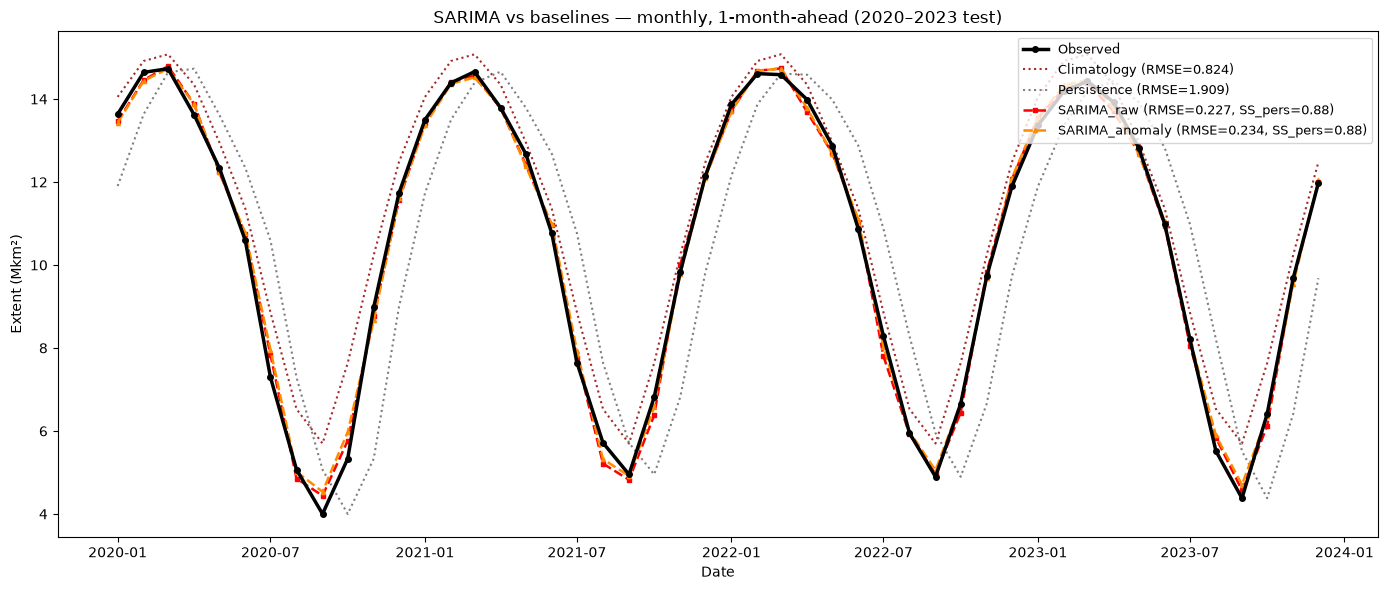

In [13]:
fig_dir = PROJECT_ROOT / "results" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, y_true, "k-o", lw=2.5, ms=4, label="Observed", zorder=5)
ax.plot(test_dates, climatology_pred, ":", color="brown", lw=1.5,
        label=f"Climatology (RMSE={metrics['climatology']['rmse']:.3f})")
ax.plot(test_dates, persistence_pred, ":", color="gray", lw=1.5,
        label=f"Persistence (RMSE={metrics['persistence']['rmse']:.3f})")
ax.plot(test_dates, forecast_raw, "--s", color="red", lw=1.8, ms=3,
        label=f"SARIMA_raw (RMSE={metrics['SARIMA_raw']['rmse']:.3f}, "
              f"SS_pers={metrics['SARIMA_raw']['skill_score_persistence']:.2f})")
ax.plot(test_dates, forecast_anom_raw, "--^", color="darkorange", lw=1.8, ms=3,
        label=f"SARIMA_anomaly (RMSE={metrics['SARIMA_anomaly']['rmse']:.3f}, "
              f"SS_pers={metrics['SARIMA_anomaly']['skill_score_persistence']:.2f})")
ax.set_title("SARIMA vs baselines — monthly, 1-month-ahead (2020–2023 test)")
ax.set_ylabel("Extent (Mkm²)")
ax.set_xlabel("Date")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(fig_dir / "sarima_monthly_2020_2023.png", dpi=120)
print("saved", fig_dir / "sarima_monthly_2020_2023.png")

## Findings

Monthly, **1-month-ahead** walk-forward, 2020–2023 test (48 months):

| Model | RMSE (Mkm²) | Skill vs persistence | Skill vs climatology | ACC |
|---|---|---|---|---|
| **SARIMA_raw** | **0.227** | **+0.88** | **+0.72** | 0.855 |
| SARIMA_anomaly | 0.234 | +0.88 | +0.72 | 0.843 |
| Climatology | 0.824 | +0.57 | — | — |
| Persistence | 1.909 | — | −1.32 | 0.10 |

**SARIMA clearly adds value at monthly scale.** SARIMA_raw beats persistence by 88% and
climatology by 72% — a genuinely skillful forecast.

**The best baseline flips with timescale (the key cross-notebook lesson).** At *daily* resolution
(`03b`) persistence dominates (RMSE 0.087) and climatology is weak (1.0). At *monthly* resolution
it inverts: month-to-month seasonal swings make persistence collapse (1.9), climatology (0.82) is
far better, and SARIMA beats both. This is exactly why models must be compared **within** a fixed
scale — the daily and monthly rows in `results/model_comparison.csv` are deliberately kept in
separate `scale` buckets.

**Anomaly modelling didn't help.** SARIMA_raw ≈ SARIMA_anomaly (0.227 vs 0.234): pre-subtracting
the month-of-year climatology added complexity without improving skill — a useful negative result.

**Seasonality.** SARIMA is ~2× more accurate in winter (RMSE 0.13) than summer (0.27), consistent
with the melt-season volatility seen in the daily baselines — summer stays the hard regime.